# **Exercise 5:** Add river inflow points discharge forcing to your model

In this exercise we will add upstream river boundaries to the model. First we will add the points where rivers are entering our model domain and after this we can add the actual discharge timeseries. We will rerun the model and see what the influence of the rivers is:

- Step 1: Read the Charleston model a change the output root
- Step 2: Add new observation points
- Step 3: Add the river inflow points
- Step 4: Add discharge timeseries to force the model
- Step 5: Run model again
- Step 6: Compare results

## **Step 0:** Import dependencies

Before anything else we need to import the required packages

In [1]:
from pathlib import Path

from hydromt.log import setuplog
from hydromt_sfincs import SfincsModel
from sfincs_utils import run_sfincs

## default answers (for testing)

In [ ]:
# step 1
model_root_old = 'sfincs_charleston_subgrid'
model_root = 'sfincs_charleston_subgrid_river'

# step 2
obs_points_fn = Path(r'geojsons\obs_points_cooper_river.geojson')

# step 3
river_inflow_kwargs = dict(
    hydrography='merit_hydro',
    river_upa=30,
    river_len=1000,
    keep_rivers_geom=True,
)

# step 4
q_start = 400
q_end = 5000


## **Step 1:** Read the model a change the output root
Now let's copy our old model to a new folder, so we can always look at the old model later on:

In [3]:
# model_root_old = 'YOUR_OLD_MODEL_ROOT'
# model_root = 'YOUR_NFW_MODEL_ROOT'

logger = setuplog('SFINCS_log_charleston', log_level=20)
sf = SfincsModel(data_libs=['data_catalog.yml'], root=model_root_old, mode='r', logger=logger)
sf.read()

# change the model root (to not overwrite existing model)
sf.set_root(model_root, mode= 'r+')

2025-12-19 13:49:52,854 - SFINCS_log_charleston - log - INFO - HydroMT version: 0.10.1
2025-12-19 13:49:52,921 - SFINCS_log_charleston - data_catalog - INFO - Parsing data catalog from data_catalog.yml
2025-12-19 13:49:52,975 - SFINCS_log_charleston - model_api - INFO - Initializing sfincs model from hydromt_sfincs (v1.2.2).
2025-12-19 13:49:53,003 - SFINCS_log_charleston - sfincs - WARNING - depfile not found at c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid\sfincs.dep
2025-12-19 13:49:53,007 - SFINCS_log_charleston - sfincs - WARNING - manningfile not found at c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid\sfincs.manning
2025-12-19 13:49:59,254 - SFINCS_log_charleston - sfincs - INFO - Model read


## **Step 2**: Add new observation points

Add observation points along the Cooper river. In order to do so, create a new geojson file with observation points and use the `setup_observations_points` function to add those points to the SFINCS model. If you do not remember anymore how to do this, look at the first notebook 'SFINCS_course_setup_model.ipynb', there we used this same function.


In [4]:
# Path to observation points & lines geometries
# obs_points_fn = Path(r'geojsons\NEW_OBS_GEOJSON_FILE')

# Setup observation. merge argument handles whether to override or not
sf.setup_observation_points(locations=obs_points_fn, merge=True)

2025-12-19 13:50:02,697 - SFINCS_log_charleston - geodataframe - INFO - Reading  vector data from geojsons\obs_points_cooper_river.geojson
2025-12-19 13:50:02,718 - SFINCS_log_charleston - sfincs - INFO - Adding new observation points to existing ones.


## **Step 3:** Add river inflow points
We can add river inflow points by using the function **setup_river_inflow()** and filling in the arguments for:
<br>
- **hydrography** : This is rastered hydrography data, it needs to have an 'uparea' and 'flwdir' layer. In our case we use the global dataset 'merit_hydro'.
<br>
-  **river_len** : Mimimum river length within the model domain threshhold [m], by default 1 km.
<br>
-  **river_upa** : Minimum upstream area threshold for rivers [km2], by default 10.0
<br>

Many more arguments are possible for this function, see:
https://deltares.github.io/hydromt_sfincs/latest/_generated/hydromt_sfincs.SfincsModel.setup_river_inflow.html

2025-12-19 13:55:37,853 - SFINCS_log_charleston - rasterdataset - INFO - Reading merit_hydro raster data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\local_data\merit_hydro\{variable}.tif
2025-12-19 13:55:49,664 - SFINCS_log_charleston - flwdir - INFO - Found 7 inflow points.
2025-12-19 13:55:49,923 - SFINCS_log_charleston - model_grid - WARNING - Replacing grid map: msk
2025-12-19 13:55:49,928 - SFINCS_log_charleston - sfincs - INFO - Boundary cells (n=3) updated around src points.
2025-12-19 13:55:54,041 - SFINCS_log_charleston - sfincs - INFO - Writing model data to c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid_river
2025-12-19 13:55:54,049 - SFINCS_log_charleston - sfincs - INFO - Write raster file(s) for grid to 'gis' subfolder
2025-12-19 13:55:57,444 - SFINCS_log_charleston - sfincs - INFO - Write geom files
2025-12-19 13:55:57,451 - SFINCS_log_charleston - sfincs - INFO - Write vector file(s) for geoms to 'gis' subfolder
2025-12-19 13

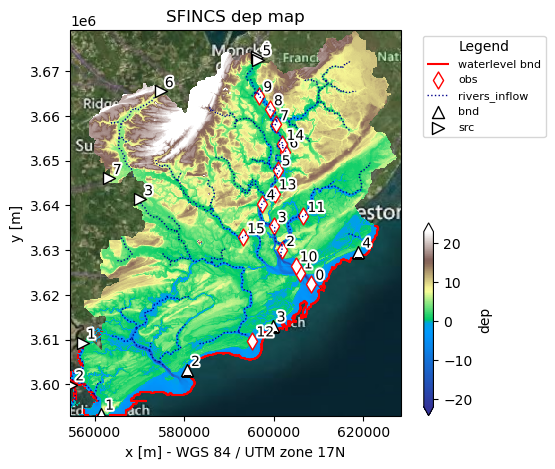

In [5]:
sf.setup_river_inflow(
    #REPLACE BY ARGUMENTS
    **river_inflow_kwargs
)

sf.plot_basemap('basemap.png', bmap='sat')

# and write the model to disk
sf.write()

### Question 1

1a) Do you get more or less river input points 'src' when increasing the 'river_upa' in 'setup_river_inflow', and what about the river length?


#### Fill in your own answers:

1a)

## **Step 4:** Add discharge timeseries to force the model. 

To add discharge timeseries to your model you could either use actual data from observations or from e.g. a hydrological model. In this exercise we however create dummy timeseries yourself. You can add discharge forcing by using the function `setup_discharge_forcing()` for adding timeseries to the src locations, or `setup_discharge_forcing_from_grid()` to derive the discharge input from a grid.

Note you could also directly change the .dis file in the model directory

In [6]:
### FILL IN YOUR FUNCTION TO ADD THE DISCHARGE HERE. You can look at the discharge forcing of your model by using sf.forcing['dis']

#Create synthetic discharge timeseries
# q_start = #DISCHARGE STARTING VALUE
# q_end = #DISCHARGE END VALUE
discharge = sf.forcing['dis'].copy()
discharge[0,3] = q_start
discharge[1,3] = q_end

sf.setup_discharge_forcing(discharge) #set discharge in model using hydroMT function

sf.forcing['dis']  # print discharge

# only write forcing
sf.write_forcing()

2025-12-19 13:56:34,023 - SFINCS_log_charleston - model_api - WARNING - Replacing forcing: dis
2025-12-19 13:56:34,026 - SFINCS_log_charleston - sfincs - INFO - Write forcing files
2025-12-19 13:56:34,053 - SFINCS_log_charleston - sfincs - INFO - Write vector file(s) for forcing.bzs to 'gis' subfolder
2025-12-19 13:56:34,099 - SFINCS_log_charleston - sfincs - INFO - Write vector file(s) for forcing.dis to 'gis' subfolder


## **Step 5:** Run model again

Run the updated model, you can do this again using the batch file

In [7]:
# NOTE you need to download the SFINCS executable first (see above) and update the path below
sfincs_exe = Path("../../00_software/SFINCS_2025_02_release", "SFINCS_v2.3.0_mt_Faber_release_exe", "sfincs.exe")

run_sfincs(
    sf.root, 
    sfincs_exe=sfincs_exe, # path to the sfincs executable if you want to run SFINCS on windows
    vm=None, # you can use 'docker' if you want to run SFINCS on linux or mac, but you need to install docker desktop first
)

>> c:\PhD\SFINCS\SFINCS_Charleston\00_software\SFINCS_2025_02_release\SFINCS_v2.3.0_mt_Faber_release_exe\sfincs.exe


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@....

### Question 2

2a) How much discharge did you add? What do you expect to happen to the model when you make this discharge unrealistically large?

#### Fill in your own answers:

2a)

## Step 6: Compare results
Compare your results; both for the gridded output and for the output at your point locations. 

Grid type not known, trying to read from config file. 
depfile not found at c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid\sfincs.dep
manningfile not found at c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid\sfincs.manning
Replacing result: inp
Replacing result: msk
Replacing result: qinf
Replacing result: zb
Replacing result: zs
Replacing result: zsmax
Replacing result: total_runtime
Replacing result: average_dt
Replacing result: status


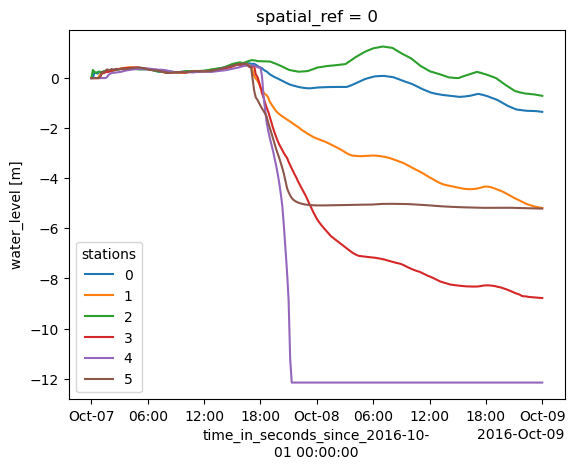

In [11]:
sf_old = SfincsModel(model_root_old, mode='r')
sf_old.read_results()
sf_old.results['point_zs'].plot.line(x='time')

2025-12-19 14:05:31,237 - SFINCS_log_charleston - sfincs - WARNING - depfile not found at c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid_river\sfincs.dep
2025-12-19 14:05:31,241 - SFINCS_log_charleston - sfincs - WARNING - manningfile not found at c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid_river\sfincs.manning
2025-12-19 14:05:31,245 - SFINCS_log_charleston - model_grid - WARNING - Replacing grid map: msk
2025-12-19 14:05:31,247 - SFINCS_log_charleston - model_grid - WARNING - Replacing grid map: scs
2025-12-19 14:05:36,449 - SFINCS_log_charleston - model_api - WARNING - Replacing geom: obs
2025-12-19 14:05:36,461 - SFINCS_log_charleston - model_api - WARNING - Replacing geom: region
2025-12-19 14:05:36,510 - SFINCS_log_charleston - model_api - WARNING - Replacing geom: rivers_inflow
2025-12-19 14:05:36,531 - SFINCS_log_charleston - model_api - WARNING - Replacing forcing: bzs
2025-12-19 14:05:36,562 - 

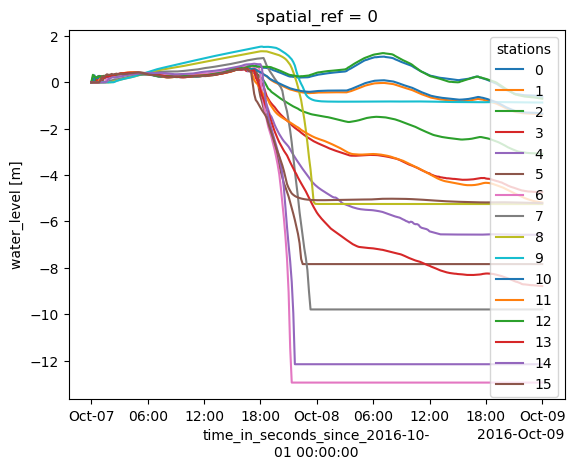

In [12]:
sf.read() #Read model

sf.results['point_zs'].plot.line(x='time') #Plot water depth timeseries

### Question 3

3a) Do you see any difference between the 2 simulations? 

3b) How far inland do you see the influence of the tides and the surge and where do you mainly see the effect of the river inflow? Compare the peak heights during the events.


#### Fill in your own answers:

3a)

3b)


## **What's Next:** Finetuning

The steps outlined above create and configure a SFINCS model ready to be ran. Building a good model however is an iterative process. Based on the outcomes of the initial simulation you might want to go back to the model configuration to finetune some aspects of the model. These can include:
- The model domain. Perhaps certain areas were left out of the first model which do add useful info. We've already seen an example above where we included teh possibility to further finetune the model domain by looking for the entire watershed of a delta. We've also seen that this left out some areas which we might want to add anyway, requiring some more finetuning
- The model boundaries. Perhaps you found that water accumulates at some boundaries because boundaries function by default as hard walls. Then you might want to specify those boundaries as outflow boundaries.
- Burn in rivers using river geometry data
- Add structures. Some regions may include weirs or dams which influence the water flow. Generally these features are smaller than the DEM resolution so are not taken into account properly. These structures can be specified manually so that they are treated more carefully.
- Update observation points. The observation geometries in this example were chosen semi-randomly. For proper model validation these can be chosen more carefully to align better with real world measurements.  

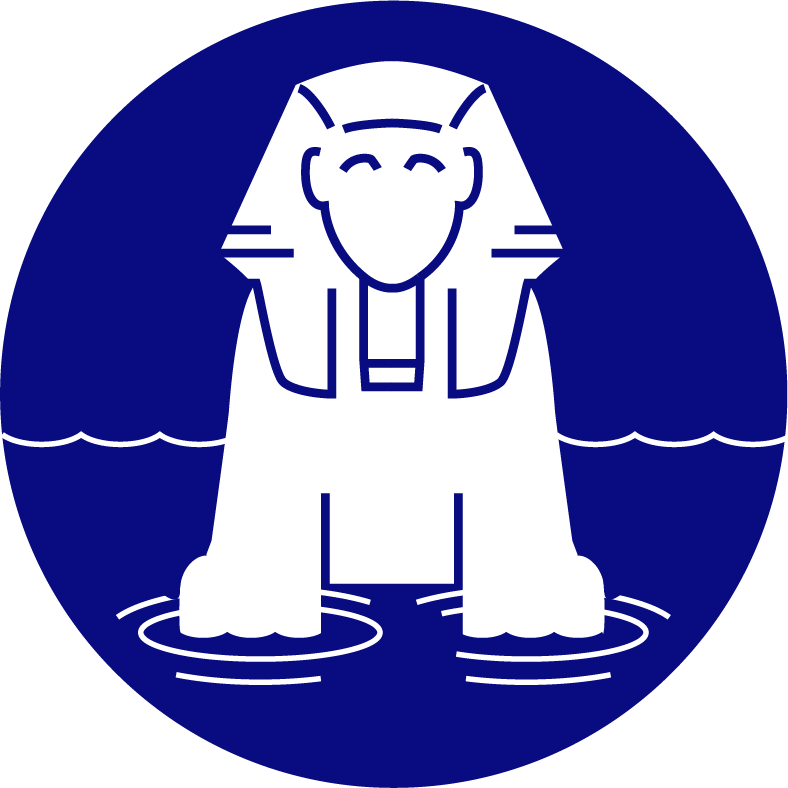